# HyperParameterTuning_ModelFinalization - Exhaustive Stage-Two Winner Search

This notebook is now configured for the **second-stage exhaustive tuning run** built around the winning models and their current best settings:
- Ridge Regression
- Elastic Net
- Random Forest Regressor
- KNN
- XGBoost
- LightGBM

Models explicitly excluded from this run:
- Linear Regression
- CatBoost
- Support Vector Regression (SVR)

Search design for this run:
- each base model is evaluated in **two feature-selection modes**
  - **without Lasso feature selection**
  - **with Lasso feature selection**
- the Lasso-enabled variants sweep alpha values across **[0.0, 1.0]**
- because `sklearn` Lasso should not be run at exact `alpha=0`, the `0.0` endpoint is executed as **`1e-6`** while still representing the near-zero edge of the requested sweep
- every base model’s search space is expanded **around the best params you supplied**
- progress artifacts still include:
  - a resumable candidate-progress CSV per model variant
  - a consolidated results checkpoint CSV
  - saved best-estimator joblib files
  - a live status CSV snapshot
  - a reduced-noise run log with checkpoint updates at least every 30 minutes

Raw string columns `title` and `release_date` remain excluded so the search stays focused on the encoded numeric feature set.


## Dataset Summary

,Metric,Value
0,Rows,"3,856"
1,Columns in source dataset,135
2,Model features used,132
3,Continuous features,35
4,Binary encoded features,97
5,Dropped raw columns,"title, release_date"
6,Total missing values in X,0
7,Revenue skewness,4.33


## Feature Groups

,Feature Group,Count,Sample columns
0,Continuous,35,"budget, runtime, actor_1_popularity, actor_2_popularity, actor_3_popularity, num_keywords, overview_word_count, tagline_word_count"
1,Binary encoded,97,"country_United States of America, country_United Kingdom, country_France, country_Germany, country_Canada, country_Japan, country_China, country_Australia"


## Optional Model Libraries

,Package,Available
0,xgboost,True
1,lightgbm,True


## Search Configuration

,Setting,Value
0,Run variant,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1
1,Base models in this exhaustive run,"Ridge Regression, Elastic Net, Random Forest Regressor, KNN"
2,Excluded models,"Linear Regression, CatBoost, Support Vector Regression (SVR), XGBoost, LightGBM"
3,Feature-selection modes,"Without Lasso, With Lasso Sweep"
4,Lasso alpha sweep,"[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] (the 0.0 endpoint is executed as 1e-6 for sklearn Lasso stability)"
5,Auto-install requested optional packages,True
6,Use all available CPU cores,True
7,Detected CPU cores at runtime,24
8,Parallel CV jobs,5
9,Per-estimator thread target,5


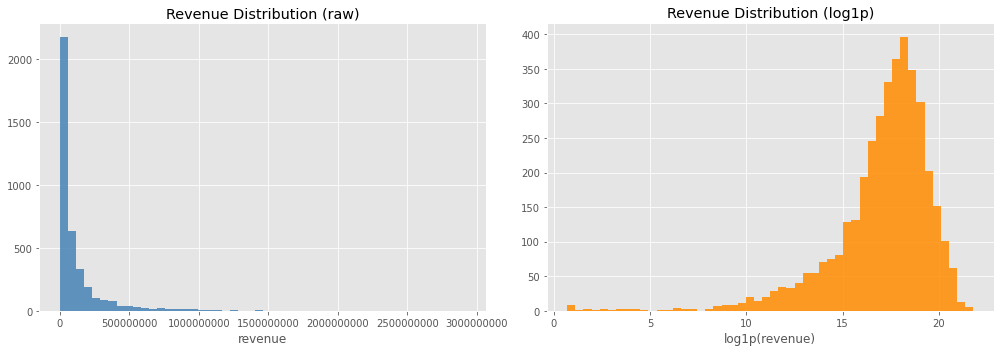

In [7]:
import math
import os

# Keep BLAS/OpenMP threads controlled so our explicit CV/model thread settings
# can scale cleanly on the target server.
# Restart the kernel after editing these values.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import hashlib
import importlib
import json
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
    PLOTTING_AVAILABLE = True
except ImportError:
    plt = None
    PLOTTING_AVAILABLE = False
from IPython.display import Markdown, display
from joblib import dump

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import KFold, ParameterGrid, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names", category=UserWarning)

AUTO_INSTALL_REQUESTED_PACKAGES = True


def import_optional_dependency(import_name, pip_name=None, auto_install=False):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        if auto_install and pip_name:
            print(f"Installing optional package `{pip_name}` for the requested model search...")
            install_process = subprocess.run(
                [sys.executable, "-m", "pip", "install", pip_name],
                capture_output=True,
                text=True,
                check=False,
            )
            if install_process.returncode == 0:
                try:
                    return importlib.import_module(import_name)
                except ImportError:
                    pass

            install_lines = (install_process.stderr or install_process.stdout or "").strip().splitlines()
            install_message = install_lines[-1] if install_lines else "installation failed"
            print(f"Optional package `{pip_name}` is still unavailable: {install_message}")
        return None


xgboost_module = import_optional_dependency(
    "xgboost",
    "xgboost",
    auto_install=AUTO_INSTALL_REQUESTED_PACKAGES,
)
lightgbm_module = import_optional_dependency(
    "lightgbm",
    "lightgbm",
    auto_install=AUTO_INSTALL_REQUESTED_PACKAGES,
)

XGBRegressor = getattr(xgboost_module, "XGBRegressor", None) if xgboost_module is not None else None
LGBMRegressor = getattr(lightgbm_module, "LGBMRegressor", None) if lightgbm_module is not None else None

pd.set_option("display.max_colwidth", 220)
pd.set_option("display.max_columns", None)
if PLOTTING_AVAILABLE:
    plt.style.use("ggplot")

DATA_PATH = Path(r"/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/Movies-Dataset-no-missing-2000-2026-ML-Ready-encoded.csv")
TARGET_COLUMN = "revenue"
EXCLUDED_COLUMNS = ["title", "release_date", TARGET_COLUMN]

BASE_MODEL_NAMES = [
    "Ridge Regression",
    "Elastic Net",
    "Random Forest Regressor",
    "KNN",
    
]
EXCLUDED_MODEL_NAMES = [
    "Linear Regression",
    "CatBoost",
    "Support Vector Regression (SVR)",
    "XGBoost",
    "LightGBM",
]
FEATURE_SELECTION_MODES = [
    "Without Lasso",
    "With Lasso Sweep",
]

MODEL_PACKAGE_AVAILABILITY = {
    "Ridge Regression": True,
    "Elastic Net": True,
    "Random Forest Regressor": True,
    "KNN": True,
    "XGBoost": XGBRegressor is not None,
    "LightGBM": LGBMRegressor is not None,
}
MODEL_PACKAGE_NAMES = {
    "XGBoost": "xgboost",
    "LightGBM": "lightgbm",
}

RAW_LASSO_ALPHA_SWEEP = np.round(np.linspace(0.0, 1.0, 11), 2).tolist()
LASSO_ALPHA_SWEEP = [
    1e-6 if np.isclose(alpha_value, 0.0) else float(alpha_value)
    for alpha_value in RAW_LASSO_ALPHA_SWEEP
]
LASSO_ALPHA_SWEEP_LABEL = (
    f"{RAW_LASSO_ALPHA_SWEEP} "
    "(the 0.0 endpoint is executed as 1e-6 for sklearn Lasso stability)"
)
LASSO_SELECTOR_THRESHOLD = "median"
LASSO_SELECTOR_MAX_ITER = 50000
LASSO_SELECTOR_TOL = 0.001


def model_name_slug(model_name):
    return (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("|", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("[", "")
        .replace("]", "")
    )


def build_variant_name(base_model_name, feature_selection_mode):
    if feature_selection_mode == "With Lasso Sweep":
        return f"{base_model_name} | With Lasso Sweep"
    return f"{base_model_name} | Without Lasso"


RUN_VARIANT_NAME = "winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1"
OUTPUT_ROOT = DATA_PATH.parent / "modeling_outputs" / "demo_04_winner_exhaustive_search"
OUTPUT_DIR = OUTPUT_ROOT / RUN_VARIANT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_RESULTS_PATH = OUTPUT_DIR / "movie_model_results_checkpoint.csv"
PROGRESS_DIR = OUTPUT_DIR / "search_progress"
PROGRESS_DIR.mkdir(parents=True, exist_ok=True)
LIVE_STATUS_PATH = OUTPUT_DIR / "live_search_status.csv"
RUN_LOG_PATH = OUTPUT_DIR / "run_status.log"
BEST_MODELS_DIR = OUTPUT_DIR / "best_model_checkpoints"
BEST_MODELS_DIR.mkdir(parents=True, exist_ok=True)

USE_ALL_AVAILABLE_CORES = True
AVAILABLE_CORES = os.cpu_count() or 1
CV_FOLDS = 5
SEARCH_N_JOBS = max(1, min(CV_FOLDS, AVAILABLE_CORES))
# For tree / boosting / KNN models we combine outer CV parallelism with per-estimator threading
# so the server can use essentially all available cores during the heavy fits.
ESTIMATOR_THREAD_TARGET = (
    max(1, int(round(AVAILABLE_CORES / SEARCH_N_JOBS)))
    if USE_ALL_AVAILABLE_CORES
    else 1
)
LOG_PROGRESS_EVERY_MINUTES = 30
PROGRESS_LOG_INTERVAL_SECONDS = LOG_PROGRESS_EVERY_MINUTES * 60
RANDOM_STATE = 42
TEST_SIZE = 0.20
FORCE_RERUN_MODELS = []

optional_library_df = pd.DataFrame({
    "Package": ["xgboost", "lightgbm"],
    "Available": [
        MODEL_PACKAGE_AVAILABILITY["XGBoost"],
        MODEL_PACKAGE_AVAILABILITY["LightGBM"],
    ],
})

unavailable_base_models = [
    model_name
    for model_name in BASE_MODEL_NAMES
    if not MODEL_PACKAGE_AVAILABILITY.get(model_name, True)
]

df = pd.read_csv(DATA_PATH)

model_features = [column for column in df.columns if column not in EXCLUDED_COLUMNS]
binary_features = [
    column
    for column in model_features
    if df[column].dropna().isin([0, 1]).all()
]
continuous_features = [column for column in model_features if column not in binary_features]

X = df[model_features].copy()
y = df[TARGET_COLUMN].astype(float).copy()

dataset_summary_df = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns in source dataset",
        "Model features used",
        "Continuous features",
        "Binary encoded features",
        "Dropped raw columns",
        "Total missing values in X",
        "Revenue skewness",
    ],
    "Value": [
        f"{len(df):,}",
        f"{df.shape[1]:,}",
        f"{len(model_features):,}",
        f"{len(continuous_features):,}",
        f"{len(binary_features):,}",
        ", ".join(EXCLUDED_COLUMNS[:-1]),
        f"{int(X.isna().sum().sum()):,}",
        f"{y.skew():.2f}",
    ],
})

feature_group_df = pd.DataFrame({
    "Feature Group": ["Continuous", "Binary encoded"],
    "Count": [len(continuous_features), len(binary_features)],
    "Sample columns": [
        ", ".join(continuous_features[:8]),
        ", ".join(binary_features[:8]),
    ],
})

search_config_df = pd.DataFrame({
    "Setting": [
        "Run variant",
        "Base models in this exhaustive run",
        "Excluded models",
        "Feature-selection modes",
        "Lasso alpha sweep",
        "Auto-install requested optional packages",
        "Use all available CPU cores",
        "Detected CPU cores at runtime",
        "Parallel CV jobs",
        "Per-estimator thread target",
        "Progress log cadence",
        "Cross-validation folds",
        "Test split",
        "Results checkpoint",
        "Live status snapshot",
        "Run log file",
        "Best-model directory",
    ],
    "Value": [
        RUN_VARIANT_NAME,
        ", ".join(BASE_MODEL_NAMES),
        ", ".join(EXCLUDED_MODEL_NAMES),
        ", ".join(FEATURE_SELECTION_MODES),
        LASSO_ALPHA_SWEEP_LABEL,
        AUTO_INSTALL_REQUESTED_PACKAGES,
        USE_ALL_AVAILABLE_CORES,
        AVAILABLE_CORES,
        SEARCH_N_JOBS,
        ESTIMATOR_THREAD_TARGET,
        f"Every {LOG_PROGRESS_EVERY_MINUTES} minutes, plus model start/finish/failures",
        CV_FOLDS,
        f"{TEST_SIZE:.0%}",
        str(CHECKPOINT_RESULTS_PATH),
        str(LIVE_STATUS_PATH),
        str(RUN_LOG_PATH),
        str(BEST_MODELS_DIR),
    ],
})

display(Markdown("## Dataset Summary"))
display(dataset_summary_df)

display(Markdown("## Feature Groups"))
display(feature_group_df)

display(Markdown("## Optional Model Libraries"))
display(optional_library_df)

display(Markdown("## Search Configuration"))
display(search_config_df)

if unavailable_base_models:
    unavailable_message = ", ".join(
        f"{model_name} (`pip install {MODEL_PACKAGE_NAMES[model_name]}`)"
        for model_name in unavailable_base_models
    )
    display(Markdown(
        "### Availability Note\n"
        f"The following requested base models are still unavailable in the current environment and will be skipped: {unavailable_message}."
    ))

if PLOTTING_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(y, bins=50, color="steelblue", alpha=0.85)
    axes[0].set_title("Revenue Distribution (raw)")
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].ticklabel_format(style="plain", axis="x")

    axes[1].hist(np.log1p(y), bins=50, color="darkorange", alpha=0.85)
    axes[1].set_title("Revenue Distribution (log1p)")
    axes[1].set_xlabel(f"log1p({TARGET_COLUMN})")

    plt.tight_layout()
    plt.show()
else:
    display(Markdown("Plotting skipped because matplotlib is not installed in this environment."))


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)


def build_linear_preprocessor():
    continuous_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    binary_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])
    return ColumnTransformer([
        ("continuous", continuous_pipe, continuous_features),
        ("binary", binary_pipe, binary_features),
    ])


def build_tree_preprocessor():
    continuous_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    binary_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])
    return ColumnTransformer([
        ("continuous", continuous_pipe, continuous_features),
        ("binary", binary_pipe, binary_features),
    ])


def make_lasso_selector():
    return SelectFromModel(
        estimator=Lasso(
            alpha=LASSO_ALPHA_SWEEP[0],
            max_iter=LASSO_SELECTOR_MAX_ITER,
            tol=LASSO_SELECTOR_TOL,
        ),
        threshold=LASSO_SELECTOR_THRESHOLD,
    )


def build_variant_pipeline(preprocessor, regressor, with_lasso):
    steps = [("preprocessor", preprocessor)]
    if with_lasso:
        steps.append(("feature_selection", make_lasso_selector()))
    steps.append(("regressor", regressor))
    return Pipeline(steps)


def build_variant_param_grid(base_grid, with_lasso):
    param_grid = dict(base_grid)
    if with_lasso:
        param_grid["feature_selection__estimator__alpha"] = LASSO_ALPHA_SWEEP
    return [param_grid]


cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}


def robust_scaler():
    return RobustScaler()


def standard_scaler():
    return StandardScaler()


def minmax_scaler():
    return MinMaxScaler()


base_model_blueprints = {
    "Ridge Regression": {
        "family": "Linear",
        "interpretability": "High",
        "preprocessor_type": "linear",
        "regressor_factory": lambda: Ridge(),
        "param_grid": {
            "preprocessor__continuous__scaler": [
                robust_scaler(),
                standard_scaler(),
            ],
            "regressor__alpha": [3.0, 10.0, 30.0],
        },
    },
    "Elastic Net": {
        "family": "Linear",
        "interpretability": "High",
        "preprocessor_type": "linear",
        "regressor_factory": lambda: ElasticNet(
            max_iter=15000,
            random_state=RANDOM_STATE,
            selection="cyclic",
        ),
        "param_grid": {
            "preprocessor__continuous__scaler": [
                robust_scaler(),
                standard_scaler(),
            ],
            "regressor__alpha": [0.03, 0.1, 0.3],
            "regressor__l1_ratio": [0.7, 0.8, 0.9],
        },
    },
    "Random Forest Regressor": {
        "family": "Tree-based",
        "interpretability": "Medium",
        "preprocessor_type": "tree",
        "regressor_factory": lambda: RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=ESTIMATOR_THREAD_TARGET,
        ),
        "param_grid": {
            "regressor__n_estimators": [400, 600, 800],
            "regressor__max_depth": [10, 12, 14],
            "regressor__max_features": [0.4, 0.5, 0.6],
            "regressor__min_samples_leaf": [1, 2],
        },
    },
    "KNN": {
        "family": "Instance-based",
        "interpretability": "Medium",
        "preprocessor_type": "linear",
        "regressor_factory": lambda: KNeighborsRegressor(
            n_jobs=ESTIMATOR_THREAD_TARGET,
        ),
        "param_grid": {
            "preprocessor__continuous__scaler": [
                robust_scaler(),
                standard_scaler(),
            ],
            "regressor__n_neighbors": [11, 15, 21],
            "regressor__weights": ["uniform", "distance"],
            "regressor__p": [1, 2],
        },
    },
    "XGBoost": {
        "family": "Boosting",
        "interpretability": "Low",
        "preprocessor_type": "tree",
        "regressor_factory": lambda: XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=ESTIMATOR_THREAD_TARGET,
            tree_method="hist",
            eval_metric="rmse",
            objective="reg:squarederror",
            verbosity=0,
        ),
        "param_grid": {
            "regressor__colsample_bytree": [0.8, 0.9],
            "regressor__learning_rate": [0.02, 0.03],
            "regressor__max_depth": [5, 6, 7],
            "regressor__min_child_weight": [1, 3],
            "regressor__n_estimators": [400, 600],
            "regressor__subsample": [0.8, 0.9],
        },
    },
    "LightGBM": {
        "family": "Boosting",
        "interpretability": "Low",
        "preprocessor_type": "tree",
        "regressor_factory": lambda: LGBMRegressor(
            random_state=RANDOM_STATE,
            n_jobs=ESTIMATOR_THREAD_TARGET,
            verbosity=-1,
            force_col_wise=True,
        ),
        "param_grid": {
            "regressor__learning_rate": [0.02, 0.03],
            "regressor__min_child_samples": [10, 20, 30],
            "regressor__n_estimators": [600, 800, 1000],
            "regressor__num_leaves": [24, 31, 40],
        },
    },
}


def build_preprocessor(preprocessor_type):
    if preprocessor_type == "linear":
        return build_linear_preprocessor()
    return build_tree_preprocessor()


model_specs = {}
for base_model_name in BASE_MODEL_NAMES:
    if base_model_name not in base_model_blueprints:
        continue
    if not MODEL_PACKAGE_AVAILABILITY.get(base_model_name, True):
        continue

    blueprint = base_model_blueprints[base_model_name]
    for feature_selection_mode in FEATURE_SELECTION_MODES:
        with_lasso = feature_selection_mode == "With Lasso Sweep"
        model_name = build_variant_name(base_model_name, feature_selection_mode)
        model_specs[model_name] = {
            "base_model": base_model_name,
            "feature_selection_mode": feature_selection_mode,
            "family": blueprint["family"],
            "interpretability": blueprint["interpretability"],
            "pipeline": build_variant_pipeline(
                build_preprocessor(blueprint["preprocessor_type"]),
                blueprint["regressor_factory"](),
                with_lasso=with_lasso,
            ),
            "param_grid": build_variant_param_grid(
                blueprint["param_grid"],
                with_lasso=with_lasso,
            ),
        }

ACTIVE_MODEL_NAMES = list(model_specs.keys())
ACTIVE_BASE_MODEL_NAMES = sorted({
    model_specs[model_name]["base_model"]
    for model_name in ACTIVE_MODEL_NAMES
})

RESULT_COLUMN_DEFAULTS = {
    "Model": "",
    "Base Model": "",
    "Feature Selection Mode": "",
    "Family": "",
    "Run Variant": "",
    "Lasso Enabled": False,
    "Lasso Alpha": np.nan,
    "Lasso Threshold": np.nan,
    "Lasso Selected Features": np.nan,
    "Lasso Total Features": np.nan,
    "Candidates Searched": np.nan,
    "Estimated CV Fits": np.nan,
    "Failed Candidates": 0,
    "Search Time (s)": np.nan,
    "Best CV RMSE": np.nan,
    "Best CV MAE": np.nan,
    "Best CV R2": np.nan,
    "Train RMSE": np.nan,
    "Test RMSE": np.nan,
    "Train MAE": np.nan,
    "Test MAE": np.nan,
    "Train MedianAE": np.nan,
    "Test MedianAE": np.nan,
    "Train R2": np.nan,
    "Test R2": np.nan,
    "RMSE Gap": np.nan,
    "R2 Gap": np.nan,
    "Best Params": "",
    "Model Checkpoint": "",
    "Candidate Progress File": "",
}


def write_dataframe_checkpoint(df, path):
    path = Path(path)
    temp_path = path.with_name(f"{path.stem}__tmp{path.suffix}")
    df.to_csv(temp_path, index=False)
    temp_path.replace(path)
    return path


def iter_param_candidates(param_grid):
    grid_list = param_grid if isinstance(param_grid, list) else [param_grid]
    for grid in grid_list:
        for params in ParameterGrid(grid):
            yield params


def full_candidate_space(param_grid):
    return sum(1 for _ in iter_param_candidates(param_grid))


def model_progress_path(model_name):
    return PROGRESS_DIR / f"{model_name_slug(model_name)}_candidate_progress.csv"


def model_checkpoint_path(model_name):
    return BEST_MODELS_DIR / f"{model_name_slug(model_name)}_best_estimator.joblib"


def serialize_param_value(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (list, tuple)):
        return [serialize_param_value(item) for item in value]
    if hasattr(value, "get_params"):
        shallow_params = value.get_params(deep=False)
        return {
            "class": value.__class__.__name__,
            "params": {
                key: serialize_param_value(shallow_params[key])
                for key in sorted(shallow_params)
            },
        }
    return repr(value)


def param_signature(params):
    payload = json.dumps(
        {
            key: serialize_param_value(value)
            for key, value in sorted(params.items())
        },
        sort_keys=True,
    )
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()


def normalize_results_df(results_df):
    if results_df is None or len(results_df) == 0:
        return pd.DataFrame(columns=list(RESULT_COLUMN_DEFAULTS))

    results_df = results_df.copy()
    if "Lasso Applied" in results_df.columns and "Lasso Enabled" not in results_df.columns:
        results_df = results_df.rename(columns={"Lasso Applied": "Lasso Enabled"})

    for column_name, default_value in RESULT_COLUMN_DEFAULTS.items():
        if column_name not in results_df.columns:
            results_df[column_name] = default_value

    if "Model" in results_df.columns:
        results_df = results_df.dropna(subset=["Model"]).copy()
        results_df["Model"] = results_df["Model"].astype(str)

    return results_df


def load_existing_results_checkpoint():
    if not CHECKPOINT_RESULTS_PATH.exists():
        return pd.DataFrame(columns=list(RESULT_COLUMN_DEFAULTS))

    try:
        existing_results_df = pd.read_csv(CHECKPOINT_RESULTS_PATH)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=list(RESULT_COLUMN_DEFAULTS))

    if "Model" not in existing_results_df.columns:
        return pd.DataFrame(columns=list(RESULT_COLUMN_DEFAULTS))

    existing_results_df = normalize_results_df(existing_results_df)
    existing_results_df = existing_results_df[
        existing_results_df["Model"].isin(ACTIVE_MODEL_NAMES)
    ].copy()

    if FORCE_RERUN_MODELS:
        existing_results_df = existing_results_df[
            ~existing_results_df["Model"].isin(FORCE_RERUN_MODELS)
        ].copy()

    existing_results_df = existing_results_df.drop_duplicates(subset="Model", keep="last")
    return existing_results_df.reset_index(drop=True)


def load_model_candidate_progress(model_name):
    progress_path = model_progress_path(model_name)
    if model_name in FORCE_RERUN_MODELS or not progress_path.exists():
        return pd.DataFrame()

    try:
        progress_df = pd.read_csv(progress_path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()

    if "Param Signature" not in progress_df.columns:
        return pd.DataFrame()

    progress_df = progress_df.drop_duplicates(subset="Param Signature", keep="last")
    return progress_df.sort_values("Candidate Index").reset_index(drop=True)


def completed_candidate_progress(progress_df):
    if progress_df.empty or "Status" not in progress_df.columns:
        return pd.DataFrame()
    return progress_df.loc[progress_df["Status"] == "completed"].copy()


def failed_candidate_progress(progress_df):
    if progress_df.empty or "Status" not in progress_df.columns:
        return pd.DataFrame()
    return progress_df.loc[progress_df["Status"] == "failed"].copy()


def attempted_candidate_progress(progress_df):
    if progress_df.empty or "Status" not in progress_df.columns:
        return pd.DataFrame()
    return progress_df.loc[progress_df["Status"].isin(["completed", "failed"])].copy()


def best_candidate_row(progress_df):
    completed_df = completed_candidate_progress(progress_df)
    if completed_df.empty:
        return None
    return completed_df.sort_values(["CV RMSE", "Candidate Index"]).iloc[0]


def model_candidate_progress_summary(model_name):
    total_candidates = full_candidate_space(model_specs[model_name]["param_grid"])
    progress_df = load_model_candidate_progress(model_name)
    attempted_df = attempted_candidate_progress(progress_df)
    completed_df = completed_candidate_progress(progress_df)
    failed_df = failed_candidate_progress(progress_df)

    completed_candidates = int(completed_df["Param Signature"].nunique()) if not completed_df.empty else 0
    failed_candidates = int(failed_df["Param Signature"].nunique()) if not failed_df.empty else 0
    attempted_candidates = int(attempted_df["Param Signature"].nunique()) if not attempted_df.empty else 0
    pending_candidates = max(0, total_candidates - attempted_candidates)
    progress_ratio = (attempted_candidates / total_candidates) if total_candidates else 1.0

    if completed_df.empty:
        best_cv_rmse = np.nan
        last_candidate_index = np.nan
        last_completed_at = ""
    else:
        best_row = completed_df.sort_values(["CV RMSE", "Candidate Index"]).iloc[0]
        last_row = completed_df.sort_values("Candidate Index").iloc[-1]
        best_cv_rmse = float(best_row["CV RMSE"])
        last_candidate_index = int(last_row["Candidate Index"])
        last_completed_at = str(last_row.get("Completed At", ""))

    if not completed_df.empty:
        average_candidate_seconds = float(completed_df["Candidate Time (s)"].mean())
    elif not attempted_df.empty:
        average_candidate_seconds = float(attempted_df["Candidate Time (s)"].mean())
    else:
        average_candidate_seconds = np.nan

    if pd.notna(average_candidate_seconds):
        eta_seconds = pending_candidates * average_candidate_seconds
    else:
        eta_seconds = np.nan

    return {
        "Candidates searched": total_candidates,
        "Completed candidates": completed_candidates,
        "Failed candidates": failed_candidates,
        "Pending candidates": pending_candidates,
        "Progress %": progress_ratio,
        "Best CV RMSE so far": best_cv_rmse,
        "Last completed candidate": last_candidate_index,
        "Last completed at": last_completed_at,
        "Average candidate time (s)": average_candidate_seconds,
        "Estimated remaining search time (s)": eta_seconds,
    }


def build_checkpoint_status(model_name, completed_models):
    progress_summary = model_candidate_progress_summary(model_name)
    if model_name in completed_models:
        return "completed - will skip"
    if progress_summary["Pending candidates"] == 0 and progress_summary["Failed candidates"] > 0:
        return "all candidates attempted - includes failures"
    if progress_summary["Pending candidates"] == 0 and progress_summary["Candidates searched"] > 0:
        return "all candidates complete - awaiting final refit/result row"
    if progress_summary["Completed candidates"] > 0 or progress_summary["Failed candidates"] > 0:
        next_candidate = min(
            progress_summary["Completed candidates"] + progress_summary["Failed candidates"] + 1,
            progress_summary["Candidates searched"],
        )
        return f"resume from candidate {next_candidate}"
    return "pending - fresh run"


def build_live_search_status_snapshot(completed_models):
    status_rows = []
    for model_name in ACTIVE_MODEL_NAMES:
        summary = model_candidate_progress_summary(model_name)
        status_rows.append({
            "Model": model_name,
            "Base Model": model_specs[model_name]["base_model"],
            "Feature Selection Mode": model_specs[model_name]["feature_selection_mode"],
            "Family": model_specs[model_name]["family"],
            "Interpretability": model_specs[model_name]["interpretability"],
            "Model completed": model_name in completed_models,
            "Checkpoint status": build_checkpoint_status(model_name, completed_models),
            **summary,
        })
    return pd.DataFrame(status_rows)


existing_results_df = load_existing_results_checkpoint()
completed_model_names = set(existing_results_df["Model"]) if not existing_results_df.empty else set()
PENDING_MODEL_NAMES = [
    model_name for model_name in ACTIVE_MODEL_NAMES if model_name not in completed_model_names
]

search_plan_df = build_live_search_status_snapshot(completed_model_names)
search_plan_df["Will run now"] = search_plan_df["Model"].isin(PENDING_MODEL_NAMES)
search_plan_df["Estimated CV fits remaining"] = search_plan_df["Pending candidates"] * CV_FOLDS
write_dataframe_checkpoint(search_plan_df, LIVE_STATUS_PATH)

search_plan_df = search_plan_df.sort_values(
    ["Will run now", "Base Model", "Feature Selection Mode"],
    ascending=[False, True, True],
).reset_index(drop=True)

pending_candidate_total = int(
    search_plan_df.loc[search_plan_df["Will run now"], "Pending candidates"].sum()
)
planned_fit_total = int(
    search_plan_df.loc[search_plan_df["Will run now"], "Estimated CV fits remaining"].sum()
)

search_budget_df = pd.DataFrame({
    "Metric": [
        "Base models in this run",
        "Model variants in this run",
        "Completed variants from checkpoint",
        "Pending variants this execution",
        "Pending candidates this execution",
        "Pending CV fits this execution",
    ],
    "Value": [
        len(ACTIVE_BASE_MODEL_NAMES),
        len(ACTIVE_MODEL_NAMES),
        len(completed_model_names),
        len(PENDING_MODEL_NAMES),
        f"{pending_candidate_total:,}",
        f"{planned_fit_total:,}",
    ],
})

display(Markdown("## Search Plan"))
display(search_plan_df)

display(Markdown("## Search Budget Summary"))
display(search_budget_df)


## Search Plan

,Model,Base Model,Feature Selection Mode,Family,Interpretability,Model completed,Checkpoint status,Candidates searched,Completed candidates,Failed candidates,Pending candidates,Progress %,Best CV RMSE so far,Last completed candidate,Last completed at,Average candidate time (s),Estimated remaining search time (s),Will run now,Estimated CV fits remaining
0,Elastic Net | With Lasso Sweep,Elastic Net,With Lasso Sweep,Linear,High,True,completed - will skip,198,198,0,0,1.0,1.416697e+08,198,2026-04-19 01:19:19,37.900993,0.0,False,0
1,Elastic Net | Without Lasso,Elastic Net,Without Lasso,Linear,High,True,completed - will skip,18,18,0,0,1.0,1.417330e+08,18,2026-04-18 23:13:30,0.342360,0.0,False,0
2,KNN | With Lasso Sweep,KNN,With Lasso Sweep,Instance-based,Medium,True,completed - will skip,264,264,0,0,1.0,1.419791e+08,264,2026-04-19 10:52:34,37.806133,0.0,False,0
3,KNN | Without Lasso,KNN,Without Lasso,Instance-based,Medium,True,completed - will skip,24,24,0,0,1.0,1.429633e+08,24,2026-04-19 08:04:46,0.396281,0.0,False,0
4,Random Forest Regressor | With Lasso Sweep,Random Forest Regressor,With Lasso Sweep,Tree-based,Medium,True,completed - will skip,594,594,0,0,1.0,1.829190e+08,594,2026-04-19 08:03:42,40.059669,0.0,False,0
5,Random Forest Regressor | Without Lasso,Random Forest Regressor,Without Lasso,Tree-based,Medium,True,completed - will skip,54,54,0,0,1.0,1.340954e+08,54,2026-04-19 01:24:13,4.405851,0.0,False,0
6,Ridge Regression | With Lasso Sweep,Ridge Regression,With Lasso Sweep,Linear,High,True,completed - will skip,66,66,0,0,1.0,1.417191e+08,66,2026-04-18 23:12:37,37.815419,0.0,False,0
7,Ridge Regression | Without Lasso,Ridge Regression,Without Lasso,Linear,High,True,completed - will skip,6,6,0,0,1.0,1.417101e+08,6,2026-04-18 22:30:49,0.588368,0.0,False,0


## Search Budget Summary

,Metric,Value
0,Base models in this run,4
1,Model variants in this run,8
2,Completed variants from checkpoint,8
3,Pending variants this execution,0
4,Pending candidates this execution,0
5,Pending CV fits this execution,0


In [9]:
def format_duration(seconds):
    if pd.isna(seconds):
        return ""

    total_seconds = max(0, int(round(float(seconds))))
    hours, remainder = divmod(total_seconds, 3600)
    minutes, secs = divmod(remainder, 60)

    if hours:
        return f"{hours}h {minutes}m {secs}s"
    if minutes:
        return f"{minutes}m {secs}s"
    return f"{secs}s"


def log_event(message):
    timestamp = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{timestamp}] {message}"
    print(line, flush=True)
    with RUN_LOG_PATH.open("a", encoding="utf-8") as log_file:
        log_file.write(line + "\n")


def save_results_checkpoint(results):
    partial_results_df = normalize_results_df(pd.DataFrame(results))

    if partial_results_df.empty:
        write_dataframe_checkpoint(partial_results_df, CHECKPOINT_RESULTS_PATH)
        return partial_results_df

    partial_results_df = partial_results_df.drop_duplicates(subset="Model", keep="last")
    partial_results_df = partial_results_df.sort_values("Test RMSE", na_position="last").reset_index(drop=True)
    write_dataframe_checkpoint(partial_results_df, CHECKPOINT_RESULTS_PATH)
    return partial_results_df


def save_model_candidate_progress(progress_df, model_name):
    if progress_df.empty:
        write_dataframe_checkpoint(progress_df, model_progress_path(model_name))
        return progress_df

    progress_df = progress_df.drop_duplicates(subset="Param Signature", keep="last")
    progress_df = progress_df.sort_values("Candidate Index").reset_index(drop=True)
    write_dataframe_checkpoint(progress_df, model_progress_path(model_name))
    return progress_df


def estimate_global_remaining_runtime_seconds(completed_models):
    pending_runtime_models = [
        model_name
        for model_name in ACTIVE_MODEL_NAMES
        if model_name not in completed_models
    ]

    eta_components = []
    for model_name in pending_runtime_models:
        model_eta_seconds = model_candidate_progress_summary(model_name)["Estimated remaining search time (s)"]
        if pd.notna(model_eta_seconds):
            eta_components.append(float(model_eta_seconds))

    if not eta_components:
        return np.nan
    return float(np.sum(eta_components))


def update_live_status_snapshot(completed_models):
    status_df = build_live_search_status_snapshot(completed_models)
    status_df["Will run now"] = status_df["Model"].isin([
        model_name for model_name in ACTIVE_MODEL_NAMES if model_name not in completed_models
    ])
    status_df["Estimated CV fits remaining"] = status_df["Pending candidates"] * CV_FOLDS
    write_dataframe_checkpoint(status_df, LIVE_STATUS_PATH)
    return status_df


def evaluate_candidate(spec, params):
    estimator = clone(spec["pipeline"])
    estimator.set_params(**params)
    cv_scores = cross_validate(
        estimator=estimator,
        X=X_train,
        y=y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=SEARCH_N_JOBS,
        pre_dispatch=SEARCH_N_JOBS,
        return_train_score=False,
        error_score="raise",
    )

    rmse_scores = -np.asarray(cv_scores["test_RMSE"])
    mae_scores = -np.asarray(cv_scores["test_MAE"])
    r2_scores = np.asarray(cv_scores["test_R2"])

    return {
        "CV RMSE": float(rmse_scores.mean()),
        "CV MAE": float(mae_scores.mean()),
        "CV R2": float(r2_scores.mean()),
        "CV RMSE Std": float(rmse_scores.std(ddof=0)),
        "CV MAE Std": float(mae_scores.std(ddof=0)),
        "CV R2 Std": float(r2_scores.std(ddof=0)),
        "Mean Fit Time (s)": float(np.asarray(cv_scores["fit_time"]).mean()),
        "Mean Score Time (s)": float(np.asarray(cv_scores["score_time"]).mean()),
    }


def extract_lasso_summary(best_estimator):
    lasso_selector = best_estimator.named_steps.get("feature_selection") if hasattr(best_estimator, "named_steps") else None
    lasso_applied = lasso_selector is not None

    if lasso_applied:
        fitted_lasso = getattr(lasso_selector, "estimator_", lasso_selector.estimator)
        lasso_alpha = getattr(fitted_lasso, "alpha", np.nan)
        lasso_threshold = getattr(lasso_selector, "threshold_", lasso_selector.threshold)
        lasso_selected_features = int(lasso_selector.get_support().sum())
        lasso_total_features = int(lasso_selector.get_support().shape[0])
    else:
        lasso_alpha = np.nan
        lasso_threshold = np.nan
        lasso_selected_features = np.nan
        lasso_total_features = np.nan

    return {
        "Lasso Enabled": lasso_applied,
        "Lasso Alpha": lasso_alpha,
        "Lasso Threshold": lasso_threshold,
        "Lasso Selected Features": lasso_selected_features,
        "Lasso Total Features": lasso_total_features,
    }


results = existing_results_df.to_dict("records") if not existing_results_df.empty else []
completed_models_runtime = set(completed_model_names)
update_live_status_snapshot(completed_models_runtime)

log_event("=" * 88)
log_event(f"Run variant: {RUN_VARIANT_NAME}")
log_event(f"Results checkpoint: {CHECKPOINT_RESULTS_PATH}")
log_event(f"Candidate progress directory: {PROGRESS_DIR}")
log_event(f"Live status snapshot: {LIVE_STATUS_PATH}")
log_event(f"Lasso alpha sweep: {LASSO_ALPHA_SWEEP_LABEL}")
log_event(
    f"Runtime parallelism: SEARCH_N_JOBS={SEARCH_N_JOBS}, "
    f"ESTIMATOR_THREAD_TARGET={ESTIMATOR_THREAD_TARGET}, AVAILABLE_CORES={AVAILABLE_CORES}"
)
log_event(f"Run log cadence: every {LOG_PROGRESS_EVERY_MINUTES} minutes plus model boundaries and failures")

if completed_model_names:
    log_event(
        "Loaded completed model variants from checkpoint: "
        + ", ".join(sorted(completed_model_names))
    )

if FORCE_RERUN_MODELS:
    log_event(
        "Force rerun requested for: "
        + ", ".join(FORCE_RERUN_MODELS)
    )

if not PENDING_MODEL_NAMES:
    log_event("All active model variants are already present in the checkpoint. Nothing new to run.")

for model_name in PENDING_MODEL_NAMES:
    spec = model_specs[model_name]
    param_candidates = list(iter_param_candidates(spec["param_grid"]))
    candidate_count = len(param_candidates)
    estimated_cv_fits = candidate_count * CV_FOLDS
    progress_df = load_model_candidate_progress(model_name)
    attempted_progress_df = attempted_candidate_progress(progress_df)
    completed_progress_df = completed_candidate_progress(progress_df)
    failed_progress_df = failed_candidate_progress(progress_df)

    finished_signatures = set(attempted_progress_df["Param Signature"]) if not attempted_progress_df.empty else set()
    completed_candidates = int(completed_progress_df["Param Signature"].nunique()) if not completed_progress_df.empty else 0
    failed_candidates = int(failed_progress_df["Param Signature"].nunique()) if not failed_progress_df.empty else 0
    pending_candidates = max(0, candidate_count - len(finished_signatures))
    last_progress_log_at = 0.0

    log_event(
        f"{model_name} | starting/resuming with {completed_candidates:,} completed, "
        f"{failed_candidates:,} failed, and {pending_candidates:,} pending candidates "
        f"({estimated_cv_fits:,} total planned CV fits)."
    )

    for candidate_index, params in enumerate(param_candidates, start=1):
        signature = param_signature(params)
        if signature in finished_signatures:
            continue

        candidate_start = time.perf_counter()
        candidate_status = "completed"
        candidate_error = ""

        try:
            candidate_metrics = evaluate_candidate(spec, params)
        except Exception as exc:
            candidate_status = "failed"
            candidate_error = f"{type(exc).__name__}: {exc}"
            candidate_metrics = {
                "CV RMSE": np.nan,
                "CV MAE": np.nan,
                "CV R2": np.nan,
                "CV RMSE Std": np.nan,
                "CV MAE Std": np.nan,
                "CV R2 Std": np.nan,
                "Mean Fit Time (s)": np.nan,
                "Mean Score Time (s)": np.nan,
            }
            log_event(
                f"{model_name} | candidate {candidate_index:,}/{candidate_count:,} failed after "
                f"{format_duration(time.perf_counter() - candidate_start)} | {candidate_error}"
            )

        candidate_elapsed = time.perf_counter() - candidate_start
        progress_row = {
            "Model": model_name,
            "Base Model": spec["base_model"],
            "Feature Selection Mode": spec["feature_selection_mode"],
            "Family": spec["family"],
            "Run Variant": RUN_VARIANT_NAME,
            "Candidate Index": candidate_index,
            "Candidate Count": candidate_count,
            "Param Signature": signature,
            "Params": str(params),
            "Status": candidate_status,
            "Error": candidate_error,
            "Candidate Time (s)": candidate_elapsed,
            "Completed At": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
            **candidate_metrics,
        }
        progress_df = pd.concat([progress_df, pd.DataFrame([progress_row])], ignore_index=True)
        progress_df = save_model_candidate_progress(progress_df, model_name)

        attempted_progress_df = attempted_candidate_progress(progress_df)
        completed_progress_df = completed_candidate_progress(progress_df)
        failed_progress_df = failed_candidate_progress(progress_df)
        finished_signatures = set(attempted_progress_df["Param Signature"]) if not attempted_progress_df.empty else set()

        completed_candidates = int(completed_progress_df["Param Signature"].nunique()) if not completed_progress_df.empty else 0
        failed_candidates = int(failed_progress_df["Param Signature"].nunique()) if not failed_progress_df.empty else 0
        remaining_candidates = max(0, candidate_count - len(finished_signatures))
        best_row = best_candidate_row(progress_df)
        best_cv_rmse = float(best_row["CV RMSE"]) if best_row is not None else np.nan

        if not completed_progress_df.empty:
            average_candidate_seconds = float(completed_progress_df["Candidate Time (s)"].mean())
        else:
            average_candidate_seconds = float(attempted_progress_df["Candidate Time (s)"].mean()) if not attempted_progress_df.empty else np.nan

        model_eta_seconds = (
            remaining_candidates * average_candidate_seconds
            if pd.notna(average_candidate_seconds)
            else np.nan
        )
        global_eta_seconds = estimate_global_remaining_runtime_seconds(completed_models_runtime)
        now_counter = time.perf_counter()
        should_log_checkpoint = (
            candidate_status == "failed"
            or completed_candidates == 1
            or remaining_candidates == 0
            or (now_counter - last_progress_log_at) >= PROGRESS_LOG_INTERVAL_SECONDS
        )

        if should_log_checkpoint:
            log_event(
                f"{model_name} | checkpoint after candidate {candidate_index:,}/{candidate_count:,} | "
                f"completed={completed_candidates:,}, failed={failed_candidates:,}, pending={remaining_candidates:,} "
                f"({len(finished_signatures) / candidate_count:.1%} attempted) | "
                f"best CV RMSE so far={best_cv_rmse:,.0f} | "
                f"last candidate={candidate_status} in {format_duration(candidate_elapsed)} | "
                f"model ETA~{format_duration(model_eta_seconds)} | "
                f"global ETA~{format_duration(global_eta_seconds)}"
            )
            last_progress_log_at = now_counter

        update_live_status_snapshot(completed_models_runtime)

    progress_df = load_model_candidate_progress(model_name)
    attempted_progress_df = attempted_candidate_progress(progress_df)
    completed_progress_df = completed_candidate_progress(progress_df)
    failed_progress_df = failed_candidate_progress(progress_df)

    if completed_progress_df.empty:
        log_event(
            f"{model_name} | no successful candidates were completed, so the model result row was not finalized."
        )
        update_live_status_snapshot(completed_models_runtime)
        continue

    attempted_candidates = int(attempted_progress_df["Param Signature"].nunique()) if not attempted_progress_df.empty else 0
    if attempted_candidates < candidate_count:
        log_event(
            f"{model_name} | search paused with {attempted_candidates:,}/{candidate_count:,} candidates attempted. "
            "Rerun this cell to continue from the saved progress file."
        )
        update_live_status_snapshot(completed_models_runtime)
        continue

    if not failed_progress_df.empty:
        log_event(
            f"{model_name} | completed the search with {len(failed_progress_df):,} failed candidate rows. "
            "Final refit will use the best successful candidate only."
        )

    best_row = best_candidate_row(progress_df)
    best_candidate_index = int(best_row["Candidate Index"])
    best_params = param_candidates[best_candidate_index - 1]

    log_event(
        f"{model_name} | all candidates attempted. Final refit starting with candidate "
        f"{best_candidate_index:,}/{candidate_count:,}."
    )
    final_fit_start = time.perf_counter()
    best_estimator = clone(spec["pipeline"])
    best_estimator.set_params(**best_params)
    best_estimator.fit(X_train, y_train)
    final_fit_elapsed = time.perf_counter() - final_fit_start

    lasso_summary = extract_lasso_summary(best_estimator)
    train_predictions = best_estimator.predict(X_train)
    test_predictions = best_estimator.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    train_mae = mean_absolute_error(y_train, train_predictions)
    test_mae = mean_absolute_error(y_test, test_predictions)
    train_median_ae = median_absolute_error(y_train, train_predictions)
    test_median_ae = median_absolute_error(y_test, test_predictions)
    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)

    final_model_checkpoint_path = model_checkpoint_path(model_name)
    dump(best_estimator, final_model_checkpoint_path)

    total_search_elapsed = float(completed_progress_df["Candidate Time (s)"].sum() + final_fit_elapsed)
    results.append({
        "Model": model_name,
        "Base Model": spec["base_model"],
        "Feature Selection Mode": spec["feature_selection_mode"],
        "Family": spec["family"],
        "Run Variant": RUN_VARIANT_NAME,
        **lasso_summary,
        "Candidates Searched": candidate_count,
        "Estimated CV Fits": estimated_cv_fits,
        "Failed Candidates": int(failed_progress_df["Param Signature"].nunique()) if not failed_progress_df.empty else 0,
        "Search Time (s)": total_search_elapsed,
        "Best CV RMSE": float(best_row["CV RMSE"]),
        "Best CV MAE": float(best_row["CV MAE"]),
        "Best CV R2": float(best_row["CV R2"]),
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train MedianAE": train_median_ae,
        "Test MedianAE": test_median_ae,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "RMSE Gap": test_rmse - train_rmse,
        "R2 Gap": train_r2 - test_r2,
        "Best Params": str(best_params),
        "Model Checkpoint": str(final_model_checkpoint_path),
        "Candidate Progress File": str(model_progress_path(model_name)),
    })

    completed_models_runtime.add(model_name)
    results_df = save_results_checkpoint(results)
    update_live_status_snapshot(completed_models_runtime)
    log_event(
        f"{model_name} | final refit finished in {format_duration(final_fit_elapsed)} | "
        f"test RMSE={test_rmse:,.0f} | test R2={test_r2:.4f}"
    )
    log_event(f"{model_name} | saved best estimator to {final_model_checkpoint_path}")
    log_event(f"{model_name} | results checkpoint updated at {CHECKPOINT_RESULTS_PATH}")

results_df = save_results_checkpoint(results)
update_live_status_snapshot(completed_models_runtime)
results_df


[2026-04-19 13:31:46] ========================================================================================
[2026-04-19 13:31:46] Run variant: winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1
[2026-04-19 13:31:46] Results checkpoint: /Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/movie_model_results_checkpoint.csv
[2026-04-19 13:31:46] Candidate progress directory: /Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress
[2026-04-19 13:31:46] Live status snapshot: /Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/live_search_status.csv
[2026-04-19 13:31:46] Lasso alpha sweep: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6,

,Model,Base Model,Feature Selection Mode,Family,Run Variant,Lasso Enabled,Lasso Alpha,Lasso Threshold,Lasso Selected Features,Lasso Total Features,Candidates Searched,Estimated CV Fits,Failed Candidates,Search Time (s),Best CV RMSE,Best CV MAE,Best CV R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MedianAE,Test MedianAE,Train R2,Test R2,RMSE Gap,R2 Gap,Best Params,Model Checkpoint,Candidate Progress File
0,KNN | Without Lasso,KNN,Without Lasso,Instance-based,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1,False,NaN,NaN,NaN,NaN,24,120,0,9.588776,1.429633e+08,7.110633e+07,0.579920,0.000000e+00,1.168459e+08,0.000000e+00,6.396800e+07,0.000000e+00,2.999108e+07,1.000000,0.594519,1.168459e+08,0.405481,"{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__n_neighbors': 11, 'regressor__p': 1, 'regressor__weights': 'distance'}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/knn___without_lasso_best_...,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress/knn___without_lasso_candidate_pr...
1,Random Forest Regressor | Without Lasso,Random Forest Regressor,Without Lasso,Tree-based,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1,False,NaN,NaN,NaN,NaN,54,270,0,241.546954,1.340954e+08,6.738414e+07,0.628739,6.044912e+07,1.181921e+08,3.660613e+07,6.420699e+07,2.163600e+07,3.257671e+07,0.925858,0.585123,5.774295e+07,0.340735,"{'regressor__max_depth': 12, 'regressor__max_features': 0.4, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 800}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/random_forest_regressor__...,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress/random_forest_regressor___withou...
2,Elastic Net | Without Lasso,Elastic Net,Without Lasso,Linear,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1,False,NaN,NaN,NaN,NaN,18,90,0,6.350077,1.417330e+08,7.801839e+07,0.586303,1.375471e+08,1.196693e+08,7.531012e+07,7.422979e+07,4.238638e+07,4.394568e+07,0.616128,0.574687,-1.787784e+07,0.041441,"{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.9}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/elastic_net___without_las...,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress/elastic_net___without_lasso_cand...
3,Ridge Regression | Without Lasso,Ridge Regression,Without Lasso,Linear,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1,False,NaN,NaN,NaN,NaN,6,30,0,3.621923,1.417101e+08,7.780942e+07,0.586447,1.375326e+08,1.196976e+08,7.532834e+07,7.426235e+07,4.239954e+07,4.413494e+07,0.616209,0.574486,-1.783496e+07,0.041723,"{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__alpha': 30.0}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/ridge_regression___withou...,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress/ridge_regression___without_lasso...
4,Elastic Net | With Lasso Sweep,Elastic Net,With Lasso Sweep,Linear,wi

## Live Search Status

,Model,Base Model,Feature Selection Mode,Family,Interpretability,Model completed,Checkpoint status,Candidates searched,Completed candidates,Failed candidates,Pending candidates,Progress %,Best CV RMSE so far,Last completed candidate,Last completed at,Average candidate time (s),Estimated remaining search time (s),Will run now,Estimated CV fits remaining
0,Ridge Regression | Without Lasso,Ridge Regression,Without Lasso,Linear,High,True,completed - will skip,6,6,0,0,100.0%,"$141,710,077",6,2026-04-18 22:30:49,1s,0s,False,0
1,Ridge Regression | With Lasso Sweep,Ridge Regression,With Lasso Sweep,Linear,High,True,completed - will skip,66,66,0,0,100.0%,"$141,719,129",66,2026-04-18 23:12:37,38s,0s,False,0
2,Elastic Net | Without Lasso,Elastic Net,Without Lasso,Linear,High,True,completed - will skip,18,18,0,0,100.0%,"$141,733,049",18,2026-04-18 23:13:30,0s,0s,False,0
3,Elastic Net | With Lasso Sweep,Elastic Net,With Lasso Sweep,Linear,High,True,completed - will skip,198,198,0,0,100.0%,"$141,669,668",198,2026-04-19 01:19:19,38s,0s,False,0
4,Random Forest Regressor | Without Lasso,Random Forest Regressor,Without Lasso,Tree-based,Medium,True,completed - will skip,54,54,0,0,100.0%,"$134,095,418",54,2026-04-19 01:24:13,4s,0s,False,0
5,Random Forest Regressor | With Lasso Sweep,Random Forest Regressor,With Lasso Sweep,Tree-based,Medium,True,completed - will skip,594,594,0,0,100.0%,"$182,918,984",594,2026-04-19 08:03:42,40s,0s,False,0
6,KNN | Without Lasso,KNN,Without Lasso,Instance-based,Medium,True,completed - will skip,24,24,0,0,100.0%,"$142,963,260",24,2026-04-19 08:04:46,0s,0s,False,0
7,KNN | With Lasso Sweep,KNN,With Lasso Sweep,Instance-based,Medium,True,completed - will skip,264,264,0,0,100.0%,"$141,979,127",264,2026-04-19 10:52:34,38s,0s,False,0


## Progress Artifacts

,Artifact,Path
0,Run log,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/run_status.log
1,Live status snapshot,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/live_search_status.csv
2,Results checkpoint,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/movie_model_results_checkpoint.csv
3,Progress directory,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress
4,Best-model directory,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints


## Last Run Log Lines

...

,Model,Base Model,Feature Selection Mode,Family,Run Variant,Lasso Enabled,Lasso Alpha,Lasso Threshold,Lasso Selected Features,Lasso Total Features,Candidates Searched,Estimated CV Fits,Failed Candidates,Search Time (s),Best CV RMSE,Best CV MAE,Best CV R2,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MedianAE,Test MedianAE,Train R2,Test R2,RMSE Gap,R2 Gap,Best Params,Model Checkpoint,Candidate Progress File
0,Elastic Net | Without Lasso,Elastic Net,Without Lasso,Linear,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1,False,NaN,NaN,NaN,NaN,18,90,0,6s,"$141,733,049","$78,018,386",0.586,"$137,547,100","$119,669,261","$75,310,120","$74,229,794","$42,386,376","$43,945,675",0.616,0.575,"$-17,877,839",0.041,"{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.9}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/elastic_net___without_las...,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress/elastic_net___without_lasso_cand...
1,Elastic Net | With Lasso Sweep,Elastic Net,With Lasso Sweep,Linear,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1,True,1.0,1.314893e+07,66.0,132.0,198,990,0,2h 5m 48s,"$141,669,668","$75,906,487",0.586,"$139,485,711","$121,214,082","$74,678,617","$73,399,814","$38,835,390","$40,936,552",0.605,0.564,"$-18,271,629",0.042,"{'feature_selection__estimator__alpha': 1.0, 'preprocessor__continuous__scaler': StandardScaler(), 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.8}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/elastic_net___with_lasso_...,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress/elastic_net___with_lasso_sweep_c...
2,KNN | Without Lasso,KNN,Without Lasso,Instance-based,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1,False,NaN,NaN,NaN,NaN,24,120,0,10s,"$142,963,260","$71,106,332",0.580,$0,"$116,845,939",$0,"$63,968,001",$0,"$29,991,077",1.000,0.595,"$116,845,939",0.405,"{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__n_neighbors': 11, 'regressor__p': 1, 'regressor__weights': 'distance'}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/knn___without_lasso_best_...,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress/knn___without_lasso_candidate_pr...
3,KNN | With Lasso Sweep,KNN,With Lasso Sweep,Instance-based,winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1,True,0.9,1.488059e+07,66.0,132.0,264,1320,0,2h 47m 4s,"$141,979,127","$68,369,454",0.585,"$947,152","$123,800,189","$41,025","$65,950,854",$0,"$29,344,285",1.000,0.545,"$122,853,037",0.455,"{'feature_selection__estimator__alpha': 0.9, 'preprocessor__continuous__scaler': RobustScaler(), 'regressor__n_neighbors': 15, 'regressor__p': 1, 'regressor__weights': 'distance'}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/knn___with_lasso_sweep_be...,/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/search_progress/knn___with_lasso_sweep_candidate...
4,Random Fores

## Best Parameters

,Model,Base Model,Feature Selection Mode,Best Params,Model Checkpoint
0,Elastic Net | Without Lasso,Elastic Net,Without Lasso,"{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.9}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/elastic_net___without_las...
1,Elastic Net | With Lasso Sweep,Elastic Net,With Lasso Sweep,"{'feature_selection__estimator__alpha': 1.0, 'preprocessor__continuous__scaler': StandardScaler(), 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.8}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/elastic_net___with_lasso_...
2,KNN | Without Lasso,KNN,Without Lasso,"{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__n_neighbors': 11, 'regressor__p': 1, 'regressor__weights': 'distance'}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/knn___without_lasso_best_...
3,KNN | With Lasso Sweep,KNN,With Lasso Sweep,"{'feature_selection__estimator__alpha': 0.9, 'preprocessor__continuous__scaler': RobustScaler(), 'regressor__n_neighbors': 15, 'regressor__p': 1, 'regressor__weights': 'distance'}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/knn___with_lasso_sweep_be...
4,Random Forest Regressor | Without Lasso,Random Forest Regressor,Without Lasso,"{'regressor__max_depth': 12, 'regressor__max_features': 0.4, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 800}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/random_forest_regressor__...
5,Random Forest Regressor | With Lasso Sweep,Random Forest Regressor,With Lasso Sweep,"{'feature_selection__estimator__alpha': 0.1, 'regressor__max_depth': 14, 'regressor__max_features': 0.4, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 600}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/random_forest_regressor__...
6,Ridge Regression | Without Lasso,Ridge Regression,Without Lasso,"{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__alpha': 30.0}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/ridge_regression___withou...
7,Ridge Regression | With Lasso Sweep,Ridge Regression,With Lasso Sweep,"{'feature_selection__estimator__alpha': 1.0, 'preprocessor__continuous__scaler': StandardScaler(), 'regressor__alpha': 30.0}",/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/best_model_checkpoints/ridge_regression___with_l...


## Lasso Summary

,Model,Base Model,Feature Selection Mode,Lasso Enabled,Lasso Alpha,Lasso Threshold,Lasso Selected Features,Lasso Total Features
0,Elastic Net | Without Lasso,Elastic Net,Without Lasso,False,,,NaN,NaN
1,Elastic Net | With Lasso Sweep,Elastic Net,With Lasso Sweep,True,1,1.31489e+07,66.0,132.0
2,KNN | Without Lasso,KNN,Without Lasso,False,,,NaN,NaN
3,KNN | With Lasso Sweep,KNN,With Lasso Sweep,True,0.9,1.48806e+07,66.0,132.0
4,Random Forest Regressor | Without Lasso,Random Forest Regressor,Without Lasso,False,,,NaN,NaN
5,Random Forest Regressor | With Lasso Sweep,Random Forest Regressor,With Lasso Sweep,True,0.1,1.50698e+07,66.0,132.0
6,Ridge Regression | Without Lasso,Ridge Regression,Without Lasso,False,,,NaN,NaN
7,Ridge Regression | With Lasso Sweep,Ridge Regression,With Lasso Sweep,True,1,1.31489e+07,66.0,132.0


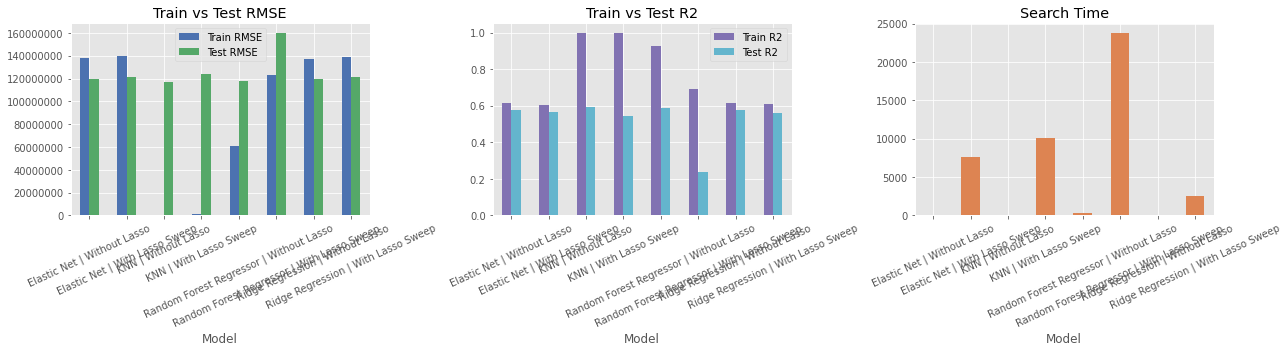

## Takeaways

- **Best overall variant so far:** **KNN | Without Lasso** with test RMSE **$116,845,939**, test MAE **$63,968,001**, and test R2 **0.595**.
- **Elastic Net:** best variant is **Without Lasso** with test RMSE **$119,669,261** and best params `{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.9}`.
- **KNN:** best variant is **Without Lasso** with test RMSE **$116,845,939** and best params `{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__n_neighbors': 11, 'regressor__p': 1, 'regressor__weights': 'distance'}`.
- **Random Forest Regressor:** best variant is **Without Lasso** with test RMSE **$118,192,075** and best params `{'regressor__max_depth': 12, 'regressor__max_features': 0.4, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 800}`.
- **Ridge Regression:** best variant is **Without Lasso** with test RMSE **$119,697,648** and best params `{'preprocessor__continuous__scaler': RobustScaler(), 'regressor__alpha': 30.0}`.
- **Feature-selection win count:** Without Lasso = 4.
- **Resume status:** there are **0** pending parameter combinations left across **0** CV fits in the current live status snapshot.
- **Lasso alpha sweep used:** `[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] (the 0.0 endpoint is executed as 1e-6 for sklearn Lasso stability)`
- **Run log:** `/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/run_status.log`
- **Live status snapshot:** `/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/live_search_status.csv`
- **Results checkpoint:** `/Users/Grad/kgiri/ML_Project/Dataset/comparison_outputs/modeling_outputs/demo_04_winner_exhaustive_search/winner_expansion_exhaustive__with_without_lasso__alpha_0_to_1/movie_model_results_checkpoint.csv`

In [10]:
if "results_df" not in globals():
    results_df = load_existing_results_checkpoint()

results_df = normalize_results_df(results_df)

if LIVE_STATUS_PATH.exists():
    try:
        live_status_df = pd.read_csv(LIVE_STATUS_PATH)
    except pd.errors.EmptyDataError:
        live_status_df = pd.DataFrame()
else:
    live_status_df = pd.DataFrame()

if live_status_df.empty:
    pending_candidate_total = 0
    planned_fit_total = 0
else:
    pending_candidate_total = int(live_status_df["Pending candidates"].sum()) if "Pending candidates" in live_status_df.columns else 0
    planned_fit_total = int(live_status_df["Estimated CV fits remaining"].sum()) if "Estimated CV fits remaining" in live_status_df.columns else 0

display(Markdown("## Live Search Status"))
if live_status_df.empty:
    display(Markdown(f"No live status snapshot found yet at `{LIVE_STATUS_PATH}`."))
else:
    live_status_display_df = live_status_df.copy()
    if "Progress %" in live_status_display_df.columns:
        live_status_display_df["Progress %"] = live_status_display_df["Progress %"].map(
            lambda value: f"{value:.1%}" if pd.notna(value) else ""
        )
    if "Best CV RMSE so far" in live_status_display_df.columns:
        live_status_display_df["Best CV RMSE so far"] = live_status_display_df["Best CV RMSE so far"].map(
            lambda value: f"${value:,.0f}" if pd.notna(value) else ""
        )
    if "Last completed candidate" in live_status_display_df.columns:
        live_status_display_df["Last completed candidate"] = live_status_display_df["Last completed candidate"].map(
            lambda value: f"{int(value):,}" if pd.notna(value) else ""
        )
    if "Estimated CV fits remaining" in live_status_display_df.columns:
        live_status_display_df["Estimated CV fits remaining"] = live_status_display_df["Estimated CV fits remaining"].map(
            lambda value: f"{int(value):,}" if pd.notna(value) else ""
        )
    if "Average candidate time (s)" in live_status_display_df.columns:
        live_status_display_df["Average candidate time (s)"] = live_status_display_df["Average candidate time (s)"].map(
            lambda value: format_duration(value) if pd.notna(value) else ""
        )
    if "Estimated remaining search time (s)" in live_status_display_df.columns:
        live_status_display_df["Estimated remaining search time (s)"] = live_status_display_df["Estimated remaining search time (s)"].map(
            lambda value: format_duration(value) if pd.notna(value) else ""
        )
    display(live_status_display_df)

display(Markdown("## Progress Artifacts"))
artifact_df = pd.DataFrame({
    "Artifact": [
        "Run log",
        "Live status snapshot",
        "Results checkpoint",
        "Progress directory",
        "Best-model directory",
    ],
    "Path": [
        str(RUN_LOG_PATH),
        str(LIVE_STATUS_PATH),
        str(CHECKPOINT_RESULTS_PATH),
        str(PROGRESS_DIR),
        str(BEST_MODELS_DIR),
    ],
})
display(artifact_df)

display(Markdown("## Last Run Log Lines"))
if RUN_LOG_PATH.exists():
    with RUN_LOG_PATH.open("r", encoding="utf-8") as log_file:
        recent_log_lines = log_file.readlines()[-35:]
    print("".join(recent_log_lines))
else:
    print(f"No log file found yet at {RUN_LOG_PATH}")

display(Markdown("## Model Comparison"))
if results_df.empty:
    display(Markdown("No fully completed model variant result rows are available yet. The live status table above shows the in-progress search, and rerunning the search cell will continue from the saved candidate checkpoints."))
else:
    results_df = results_df.sort_values(["Base Model", "Test RMSE"], na_position="last").reset_index(drop=True)
    comparison_display_df = results_df.copy()

    currency_cols = [
        "Best CV RMSE",
        "Best CV MAE",
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE",
        "Train MedianAE",
        "Test MedianAE",
        "RMSE Gap",
    ]
    for col in currency_cols:
        if col in comparison_display_df.columns:
            comparison_display_df[col] = comparison_display_df[col].map(
                lambda value: f"${value:,.0f}" if pd.notna(value) else ""
            )
    for col in ["Best CV R2", "Train R2", "Test R2", "R2 Gap"]:
        if col in comparison_display_df.columns:
            comparison_display_df[col] = comparison_display_df[col].map(
                lambda value: f"{value:.3f}" if pd.notna(value) else ""
            )
    if "Search Time (s)" in comparison_display_df.columns:
        comparison_display_df["Search Time (s)"] = comparison_display_df["Search Time (s)"].map(
            lambda value: format_duration(value) if pd.notna(value) else ""
        )
    display(comparison_display_df)

    display(Markdown("## Best Parameters"))
    display(results_df[["Model", "Base Model", "Feature Selection Mode", "Best Params", "Model Checkpoint"]])

    display(Markdown("## Lasso Summary"))
    lasso_display_df = results_df[[
        "Model",
        "Base Model",
        "Feature Selection Mode",
        "Lasso Enabled",
        "Lasso Alpha",
        "Lasso Threshold",
        "Lasso Selected Features",
        "Lasso Total Features",
    ]].copy()
    lasso_display_df["Lasso Alpha"] = lasso_display_df["Lasso Alpha"].map(
        lambda value: f"{value:.6g}" if pd.notna(value) else ""
    )
    lasso_display_df["Lasso Threshold"] = lasso_display_df["Lasso Threshold"].map(
        lambda value: f"{value:.6g}" if isinstance(value, (int, float, np.floating)) and pd.notna(value) else ("" if pd.isna(value) else str(value))
    )
    display(lasso_display_df)

    if PLOTTING_AVAILABLE:
        plot_ready_df = results_df.dropna(subset=["Train RMSE", "Test RMSE", "Train R2", "Test R2"]).copy()
        if not plot_ready_df.empty:
            rmse_plot_wide = plot_ready_df.set_index("Model")[["Train RMSE", "Test RMSE"]]
            r2_plot_wide = plot_ready_df.set_index("Model")[["Train R2", "Test R2"]]
            search_time_wide = plot_ready_df.set_index("Model")[["Search Time (s)"]]

            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            rmse_plot_wide.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"])
            axes[0].set_title("Train vs Test RMSE")
            axes[0].ticklabel_format(style="plain", axis="y")
            axes[0].tick_params(axis="x", rotation=25)

            r2_plot_wide.plot(kind="bar", ax=axes[1], color=["#8172B2", "#64B5CD"])
            axes[1].set_title("Train vs Test R2")
            axes[1].tick_params(axis="x", rotation=25)

            search_time_wide.plot(kind="bar", ax=axes[2], color=["#DD8452"], legend=False)
            axes[2].set_title("Search Time")
            axes[2].tick_params(axis="x", rotation=25)

            plt.tight_layout()
            plt.show()
        else:
            display(Markdown("Plotting skipped because there are no completed result rows with full metric columns yet."))
    else:
        display(Markdown("Plotting skipped because matplotlib is not installed in this environment."))

    takeaway_lines = []
    best_overall = results_df.dropna(subset=["Test RMSE"]).sort_values("Test RMSE").iloc[0]
    takeaway_lines.append(
        f"- **Best overall variant so far:** **{best_overall['Model']}** with test RMSE **${best_overall['Test RMSE']:,.0f}**, test MAE **${best_overall['Test MAE']:,.0f}**, and test R2 **{best_overall['Test R2']:.3f}**."
    )

    per_base_best_rows = (
        results_df.dropna(subset=["Test RMSE"])
        .sort_values(["Base Model", "Test RMSE"])
        .groupby("Base Model", as_index=False)
        .first()
    )
    for _, base_row in per_base_best_rows.iterrows():
        takeaway_lines.append(
            f"- **{base_row['Base Model']}:** best variant is **{base_row['Feature Selection Mode']}** "
            f"with test RMSE **${base_row['Test RMSE']:,.0f}** and best params `{base_row['Best Params']}`."
        )

    lasso_mode_wins = (
        per_base_best_rows["Feature Selection Mode"]
        .value_counts()
        .to_dict()
    )
    takeaway_lines.append(
        "- **Feature-selection win count:** "
        + ", ".join(
            f"{mode} = {count}"
            for mode, count in lasso_mode_wins.items()
        )
        + "."
    )
    takeaway_lines.append(
        f"- **Resume status:** there are **{pending_candidate_total:,}** pending parameter combinations left across **{planned_fit_total:,}** CV fits in the current live status snapshot."
    )
    takeaway_lines.append(f"- **Lasso alpha sweep used:** `{LASSO_ALPHA_SWEEP_LABEL}`")
    takeaway_lines.append(f"- **Run log:** `{RUN_LOG_PATH}`")
    takeaway_lines.append(f"- **Live status snapshot:** `{LIVE_STATUS_PATH}`")
    takeaway_lines.append(f"- **Results checkpoint:** `{CHECKPOINT_RESULTS_PATH}`")

    display(Markdown("## Takeaways"))
    display(Markdown("\n".join(takeaway_lines)))
